<a href="https://colab.research.google.com/github/sde2424242424-coder/2026_spring_assignments/blob/main/EDA_blood_transfusion_service_center.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Report: Blood Transfusion Service Center

**과제 주제:** 기술통계분석을 통한 EDA 보고서 작성  
**데이터셋:** `blood-transfusion-service-center`  
**작성 환경:** Google Colab  
**작성자:** Dmitrii Stetsenko

# 1. 서론 (Introduction)

## 1.1 분석 배경 및 목적

본 보고서의 목적은 **Blood Transfusion Service Center** 데이터셋을 이용하여 헌혈자 데이터의 구조를 이해하고, 향후 헌혈 여부와 관련된 패턴을 탐색하는 것이다.

이 데이터는 헌혈자의 과거 헌혈 이력을 바탕으로, 일정 기간 내 다시 헌혈할 가능성이 있는지를 분석하는 데 사용할 수 있다.  
EDA(Exploratory Data Analysis, 탐색적 데이터 분석)를 통해 데이터의 특성, 결측치 여부, 변수 분포, 변수 간 관계, 타겟 변수와의 차이를 확인하고자 한다.

## 1.2 데이터셋 설명

이 데이터셋은 OpenML에서 제공되며, 헌혈자의 기록을 포함한다. 주요 변수는 다음과 같다.

- **Recency**: 마지막 헌혈 이후 경과한 개월 수
- **Frequency**: 총 헌혈 횟수
- **Monetary**: 총 헌혈량
- **Time**: 첫 헌혈 이후 경과한 개월 수
- **target / class**: 일정 기간 내 다시 헌혈했는지 여부

## 1.3 주요 분석 질문

본 분석에서는 다음 질문에 답하고자 한다.

1. 데이터의 전체 구조는 어떠한가?
2. 결측치나 중복 데이터는 존재하는가?
3. 각 수치형 변수는 어떤 분포를 가지는가?
4. 변수 간 상관관계는 존재하는가?
5. 타겟 변수에 따라 각 변수의 분포 차이가 나타나는가?

In [1]:
# 2. 라이브러리 불러오기
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# notebook 기본 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
# 3. 데이터 불러오기
# Colab 환경에서는 아래 코드로 OpenML에서 데이터를 바로 불러올 수 있다.
data = fetch_openml(name='blood-transfusion-service-center', version=1, as_frame=True)
df = data.frame.copy()

# 열 이름 확인
df.head()

,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


# 2. 데이터 프로파일링 및 기초 탐색 (Data Profiling)

먼저 데이터의 크기, 컬럼명, 자료형, 기본 정보를 확인한다.

In [3]:
# 데이터 기본 정보 확인
print("데이터 크기 (행, 열):", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())

print("\n데이터 정보:")
df.info()

데이터 크기 (행, 열): (748, 5)

컬럼 목록:
['V1', 'V2', 'V3', 'V4', 'Class']

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V1      748 non-null    int64   
 1   V2      748 non-null    int64   
 2   V3      748 non-null    int64   
 3   V4      748 non-null    int64   
 4   Class   748 non-null    category
dtypes: category(1), int64(4)
memory usage: 24.4 KB


## 2.1 데이터 명세 확인 결과

위 결과를 통해 전체 레코드 수와 변수 수를 확인할 수 있다.  
또한 각 컬럼의 자료형을 통해 수치형 변수와 범주형 변수를 구분할 수 있다.

이 데이터셋은 비교적 작은 크기의 표 형식 데이터이며, EDA와 분류 모델 실습에 적합하다.

In [4]:
# 타겟 컬럼명 자동 탐색
possible_targets = ['Class', 'class', 'target', 'Target']
target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("선택된 타겟 컬럼:", target_col)

선택된 타겟 컬럼: Class


In [5]:
# 결측치 확인
missing_count = df.isnull().sum()
missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_ratio(%)': missing_ratio
}).sort_values(by='missing_count', ascending=False)

missing_df

,missing_count,missing_ratio(%)
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
Class,0,0.0


## 2.2 결측치(Missing Value) 분석

결측치 분석을 통해 각 변수에 누락된 값이 존재하는지 확인한다.  
결측치가 없다면 데이터 전처리가 간단해지며, 결측치가 있다면 제거 또는 대체 전략이 필요하다.

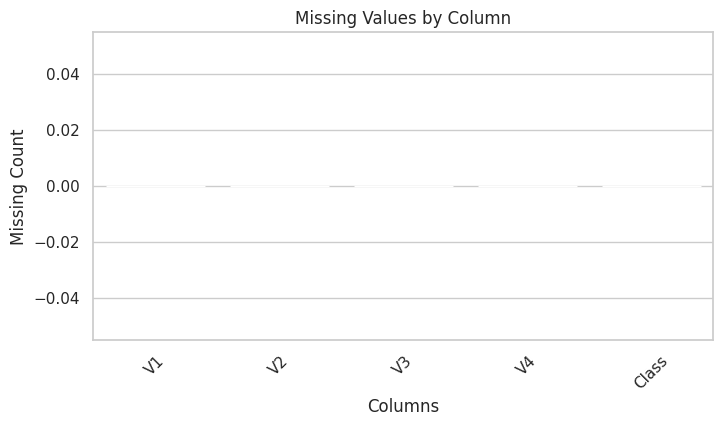

In [6]:
# 결측치 시각화
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['missing_count'])
plt.title('Missing Values by Column')
plt.xticks(rotation=45)
plt.ylabel('Missing Count')
plt.xlabel('Columns')
plt.show()

In [7]:
# 기초 통계량 확인
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
V1,748.0,NaN,NaN,NaN,9.506684,8.095396,0.0,2.75,7.0,14.0,74.0
V2,748.0,NaN,NaN,NaN,5.514706,5.839307,1.0,2.0,4.0,7.0,50.0
V3,748.0,NaN,NaN,NaN,1378.676471,1459.826781,250.0,500.0,1000.0,1750.0,12500.0
V4,748.0,NaN,NaN,NaN,34.282086,24.376714,2.0,16.0,28.0,50.0,98.0
Class,748,2,1,570,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 기초 통계량 분석

기술통계량을 통해 평균, 중앙값, 표준편차, 최소값, 최대값, 사분위수를 확인한다.  
이를 통해 변수의 스케일 차이, 분산 정도, 이상치 가능성을 파악할 수 있다.

In [8]:
# 중복 데이터 확인
duplicate_count = df.duplicated().sum()
print("중복 행 개수:", duplicate_count)

중복 행 개수: 215


## 2.4 데이터 정제(Cleaning)

중복 데이터가 존재한다면 제거를 고려할 수 있다.  
또한 변수의 자료형이 부적절한 경우 형 변환을 수행해야 한다.

In [9]:
# 수치형 / 범주형 변수 분리
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("수치형 변수:", numeric_cols)
print("범주형 변수:", categorical_cols)

수치형 변수: ['V1', 'V2', 'V3', 'V4']
범주형 변수: []


# 3. 변수별 개별 특성 분석 (Univariate Analysis)

각 변수의 개별 분포를 확인하여 데이터의 특성을 파악한다.

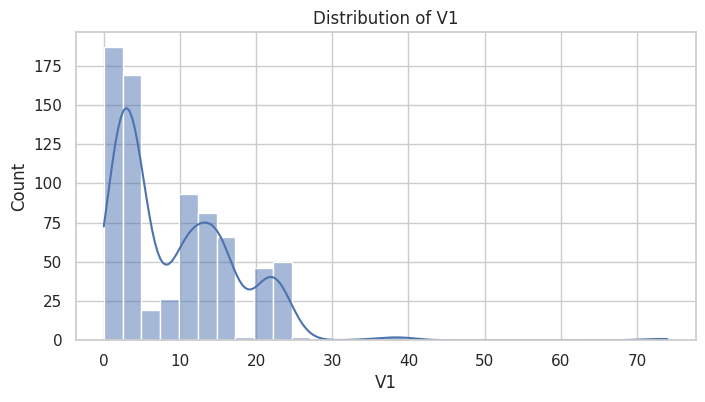

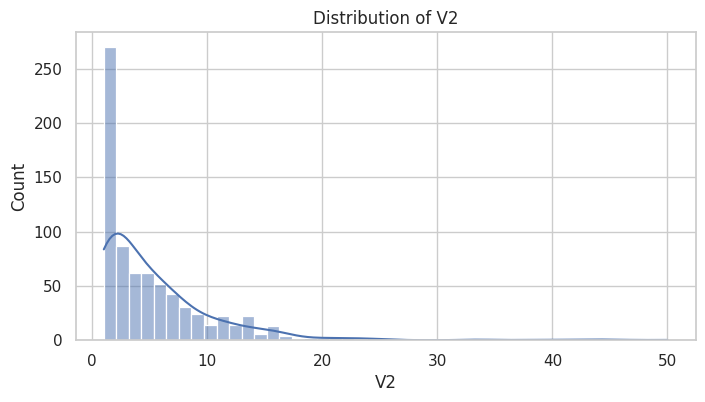

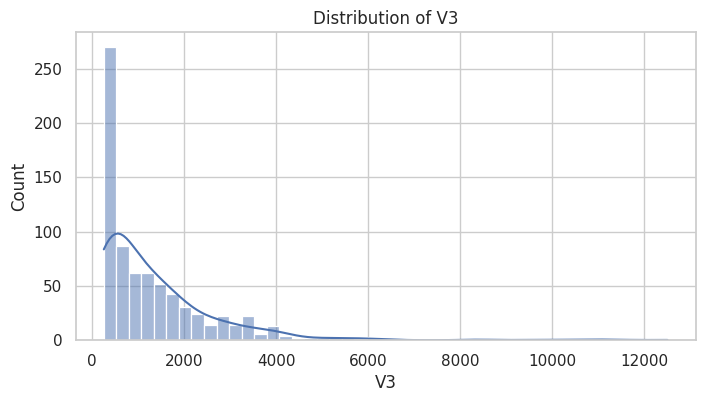

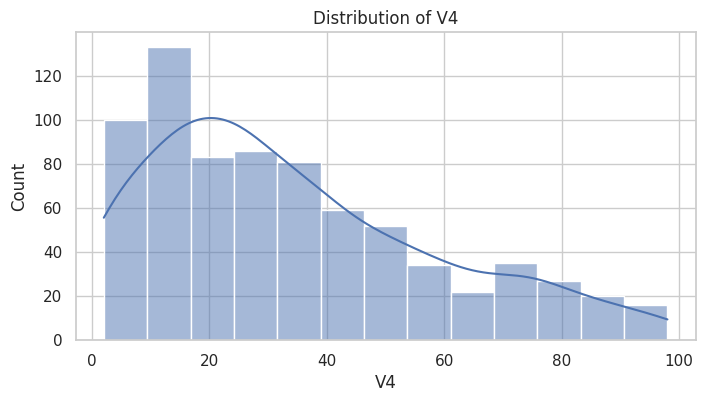

In [10]:
# 수치형 변수 분포 시각화
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [11]:
# 수치형 변수 왜도와 첨도 확인
univariate_stats = []

for col in numeric_cols:
    univariate_stats.append({
        'column': col,
        'skewness': round(df[col].skew(), 3),
        'kurtosis': round(df[col].kurt(), 3)
    })

pd.DataFrame(univariate_stats)

,column,skewness,kurtosis
0,V1,1.880,9.391
1,V2,3.211,15.876
2,V3,3.211,15.876
3,V4,0.749,-0.246


## 3.1 수치형 변수 분석 해석

- **왜도(skewness)**는 분포가 한쪽으로 치우친 정도를 의미한다.
- **첨도(kurtosis)**는 분포의 뾰족함 또는 꼬리 두께를 보여준다.

왜도가 큰 변수는 비대칭 분포일 가능성이 높으며, 첨도가 높으면 이상치의 영향이 존재할 수 있다.

In [12]:
# 타겟 변수 분포 확인
df[target_col].value_counts()

,count
Class,
1,570
2,178


In [13]:
# 타겟 변수 비율 확인
(df[target_col].value_counts(normalize=True) * 100).round(2)

,proportion
Class,
1,76.2
2,23.8


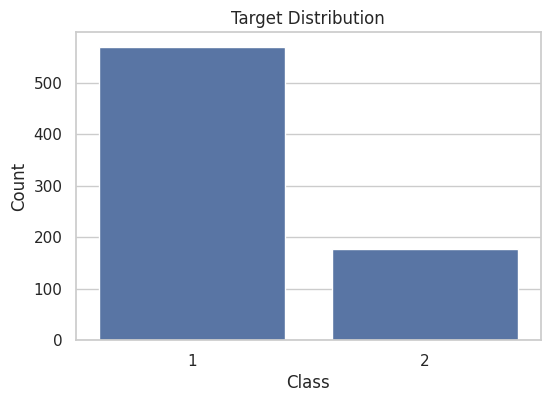

In [14]:
# 타겟 변수 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title('Target Distribution')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.show()

## 3.2 범주형 변수 분석 해석

타겟 변수의 클래스 비율을 통해 데이터가 균형 잡혀 있는지 확인할 수 있다.  
만약 특정 클래스가 지나치게 많다면, 이후 분류 모델링 단계에서 클래스 불균형 문제가 발생할 수 있다.

# 4. 상관관계 및 관계 분석 (Multivariate Analysis)

이 단계에서는 변수 간 관계와 타겟 변수에 따른 차이를 확인한다.

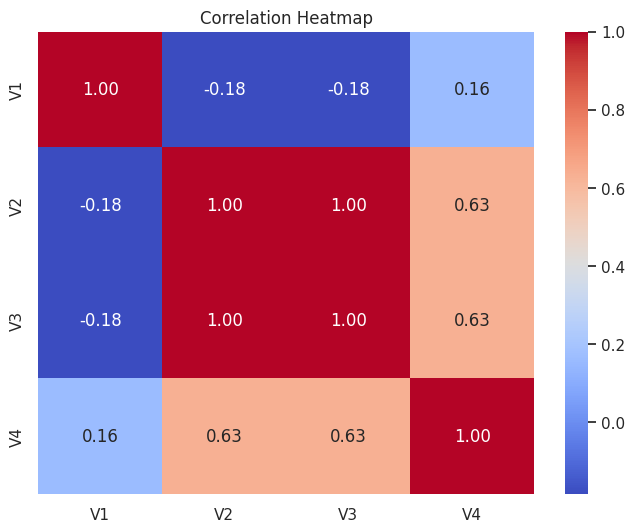

In [15]:
# 수치형 변수 상관관계
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 4.1 상관관계 분석 해석

상관관계 히트맵을 통해 수치형 변수 간 선형 관계를 확인할 수 있다.  
특히 **Frequency**와 **Monetary**는 데이터 특성상 높은 상관관계를 가질 가능성이 있다.

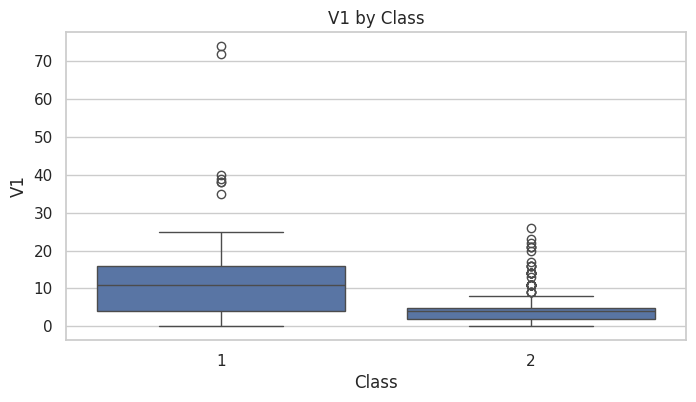

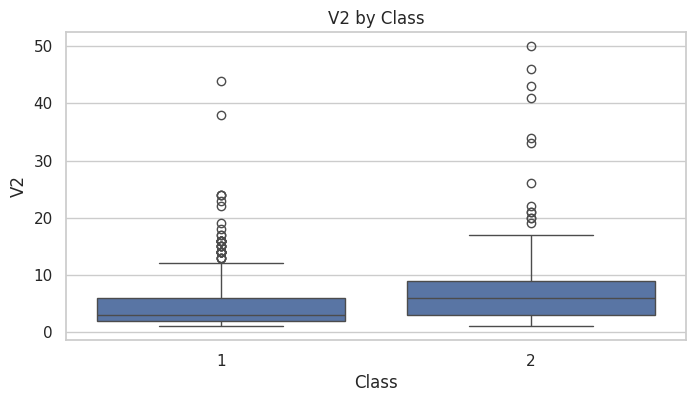

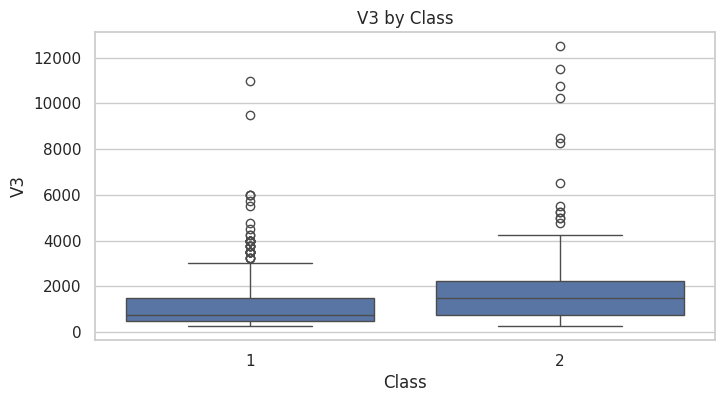

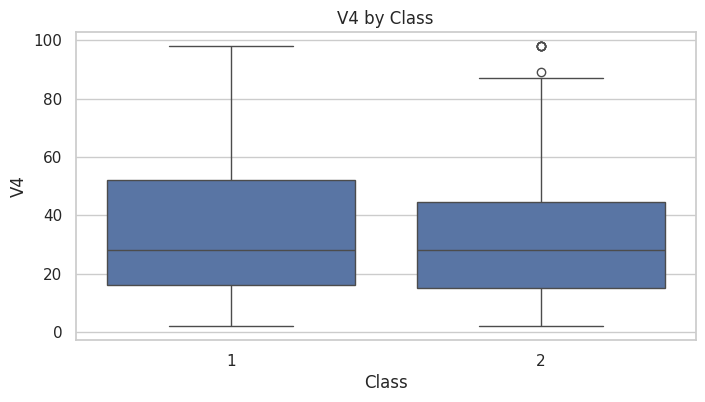

In [16]:
# 타겟 변수 기준 수치형 변수 비교
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f'{col} by {target_col}')
    plt.xlabel(target_col)
    plt.ylabel(col)
    plt.show()

## 4.2 타겟 변수 기반 심층 분석 해석

박스플롯을 통해 타겟 그룹별 중앙값, 분산, 이상치 차이를 시각적으로 확인할 수 있다.  
특정 변수에서 두 클래스 간 차이가 크다면, 해당 변수는 예측에 유용할 가능성이 있다.

In [17]:
# 대표적인 변수 관계 시각화
if all(col in df.columns for col in ['Frequency', 'Monetary']):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Frequency', y='Monetary', hue=target_col)
    plt.title('Frequency vs Monetary by Target')
    plt.xlabel('Frequency')
    plt.ylabel('Monetary')
    plt.show()

## 4.3 세그먼트 비교 분석

산점도를 통해 두 수치형 변수의 관계를 확인하고, 타겟 클래스에 따라 분포가 달라지는지 살펴볼 수 있다.

# 5. 핵심 인사이트 및 가설 검정 (Key Insights)

## 5.1 주요 패턴 발견

본 분석을 통해 다음과 같은 주요 패턴을 확인할 수 있다.

1. 데이터는 비교적 단순한 구조를 가지며, 수치형 변수 중심으로 구성되어 있다.
2. 결측치가 없거나 매우 적다면 전처리 부담이 낮다.
3. 변수별 분포는 균등하지 않으며, 일부 변수는 비대칭 분포를 보일 수 있다.
4. 변수 간 상관관계가 존재하며, 특히 헌혈 횟수와 헌혈량은 강한 관계를 보일 가능성이 높다.
5. 타겟 변수에 따라 특정 변수의 분포가 다르게 나타날 수 있다.

## 5.2 가설 검정 결과

초기 가설은 다음과 같았다.

- 헌혈 이력과 관련된 변수는 향후 헌혈 여부와 관계가 있을 것이다.
- 마지막 헌혈 시점과 총 헌혈량은 타겟과 관련된 차이를 보일 것이다.

EDA 결과를 통해 이러한 가설이 어느 정도 타당한지 시각적으로 확인할 수 있다.

## 5.3 예상치 못한 발견

- 타겟 클래스가 불균형할 수 있다.
- 일부 변수는 예상보다 넓은 범위를 가지며 이상치가 존재할 수 있다.
- 단순한 데이터 구조이지만 예측에 유용한 패턴이 포함될 가능성이 있다.

# 6. 결론 및 향후 방향 (Conclusion & Recommendation)

## 6.1 분석 요약

본 보고서에서는 Blood Transfusion Service Center 데이터셋에 대해 기술통계 기반 EDA를 수행하였다.  
데이터 구조, 결측치, 중복 여부, 기술통계량, 변수 분포, 상관관계, 타겟 변수와의 관계를 확인하였다.

## 6.2 활용 가능성

이 데이터는 향후 헌혈 여부를 예측하는 분류 모델 구축에 활용할 수 있다.  
EDA 결과는 중요한 변수 후보를 찾는 데 도움이 되며, 이후 머신러닝 전처리 및 모델링의 기초 자료가 된다.

## 6.3 한계점 및 추후 과제

본 분석은 EDA 단계에 해당하므로 인과관계를 증명하지는 않는다.  
향후에는 다음과 같은 추가 작업이 가능하다.

- 클래스 불균형 여부에 따른 처리
- train/test 분할
- 분류 모델(Logistic Regression, Random Forest 등) 적용
- 성능 평가(Accuracy, Precision, Recall, F1-score)